## Food Ordering Pattern Analysis using FP-Growth Algorithm

This notebook demonstrates Association Rule Mining on a food delivery dataset using the FP-Growth algorithm to find commonly ordered item combinations.

## Requirements:
- pandas
- mlxtend
- matplotlib
- seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import time
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Setting visualization style
plt.style.use('ggplot')
sns.set_palette("viridis")

## 1. Data Preparation

We load the dataset and convert the Items_List column into a transaction format (list of lists).

We apply One-Hot Encoding to convert the transactions into a binary matrix format where:

- Each column represents a unique item
- Each row represents a transaction
- Value = True if item exists, otherwise False

This is required because the FP-Growth algorithm works on boolean data.

In [2]:
# Load dataset
file_path = 'final_dataset2.csv'
df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')

# Convert string to list
transactions = df['Items_List'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
).tolist()

print(f"Total orders: {len(transactions)}")
print("Sample transaction:", transactions[0])

# Encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

print("Encoded DataFrame Shape:", encoded_df.shape)
encoded_df.head()

Total orders: 20000
Sample transaction: ['Crispy Sandwich', 'Mozzarella Sticks', 'Juice']
Encoded DataFrame Shape: (20000, 46)


,7UP,Alfredo Pasta,BBQ Chicken Pizza,Beef Burger,Big Mac,Burrito,Cheesy Bread,Chicken Bucket,Chicken Fillet,Chicken Ranch,...,Shawarma,Soda,Spaghetti Bolognese,Sprite,Taco,Tamarind Juice,Thickburger,Twister,Wings,Zinger
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


## 2. FP-Growth Implementation

We generate frequent itemsets using different support thresholds (0.05, 0.1, 0.2).

In [6]:
# FP-Growth Implementation
thresholds = [0.05, 0.1, 0.2]
frequent_results = {}
summary = []

for support in thresholds:
    start = time.time()
    
    itemsets = fpgrowth(encoded_df, min_support=support, use_colnames=True)
    
    end = time.time()
    
    frequent_results[support] = itemsets
    
    summary.append({
        "support": support,
        "num_itemsets": len(itemsets),
        "time": end - start
    })
    
    print(f"Support {support}: Found {len(itemsets)} frequent itemsets in {end-start:.4f}s")

# Summary table
summary_df = pd.DataFrame(summary)
display(summary_df)

# Choose best support
best_support = summary_df.sort_values(
    by=["num_itemsets", "support"],
    ascending=[False, False]
).iloc[0]["support"]

print(f"\nBest selected support: {best_support}")

top_itemsets = frequent_results[best_support].sort_values(
    by="support",
    ascending=False
).head(10)

# Convert frozenset → list for clean display
top_itemsets["itemsets"] = top_itemsets["itemsets"].apply(lambda x: list(x))

print("\nTop 10 Frequent Itemsets (Clean Format):")
display(top_itemsets)

Support 0.05: Found 41 frequent itemsets in 0.0709s
Support 0.1: Found 9 frequent itemsets in 0.0396s
Support 0.2: Found 2 frequent itemsets in 0.0359s


,support,num_itemsets,time
0,0.05,41,0.070862
1,0.10,9,0.039615
2,0.20,2,0.035930



Best selected support: 0.05

Top 10 Frequent Itemsets (Clean Format):


,support,itemsets
13,0.40805,[Fries]
15,0.22025,[Pepsi]
0,0.17345,[Juice]
23,0.15420,[Pepperoni Pizza]
33,0.12285,"[Pepsi, Fries]"
11,0.11245,[Thickburger]
3,0.10740,[Coke]
9,0.10710,[Koshary]
19,0.10660,[Shawarma]
2,0.09315,[Beef Burger]


## 3. Association Rules

Generate rules and filter based on:

- Confidence > 0.4
- Lift > 1

These thresholds ensure strong and meaningful relationships.

In [4]:
rules = association_rules(frequent_results[best_support], metric="lift", min_threshold=1.0)

strong_rules = rules[
    (rules['confidence'] > 0.4) &
    (rules['lift'] > 1.0)
]

print(f"Filtered to {len(strong_rules)} strong rules.")
print("\nTop 10 Rules sorted by Confidence:")

display_df = strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
display_df['antecedents'] = display_df['antecedents'].apply(lambda x: list(x))
display_df['consequents'] = display_df['consequents'].apply(lambda x: list(x))

display_df.sort_values(by='confidence', ascending=False).head(10)

Filtered to 16 strong rules.

Top 10 Rules sorted by Confidence:


,antecedents,consequents,support,confidence,lift
27,[Onion Rings],[Chicken Bucket],0.05125,0.948196,12.164158
16,[Tamarind Juice],[Koshary],0.05305,0.834776,7.794358
6,[BBQ Chicken Pizza],[Coke],0.05910,0.804629,7.491890
14,[Zinger],[Pepsi],0.05340,0.702632,3.190155
26,[Chicken Bucket],[Onion Rings],0.05125,0.657473,12.164158
9,[Potato Wedges],[Pepperoni Pizza],0.05015,0.645431,4.185675
23,[McChicken],[Fries],0.05745,0.623779,1.528682
19,[Shawarma],[Juice],0.06180,0.579737,3.342389
5,[Coke],[Fries],0.06190,0.576350,1.412450
12,[Pepsi],[Fries],0.12285,0.557775,1.366929


## 4. Visualizations

Visualizing the most frequent itemsets.

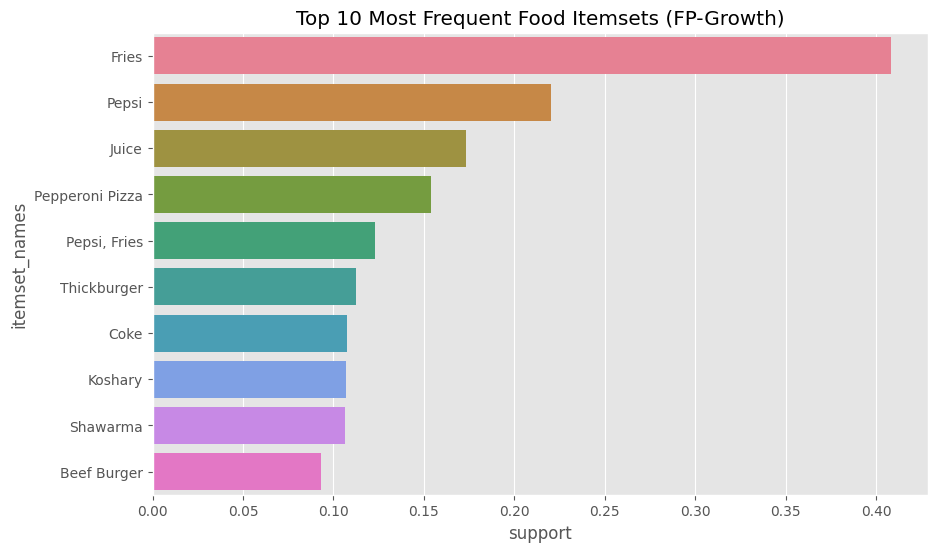

In [10]:
plt.figure(figsize=(10, 6))

top_10 = frequent_results[best_support].sort_values(
    by='support',
    ascending=False
).head(10)

top_10['itemset_names'] = top_10['itemsets'].apply(
    lambda x: ', '.join(list(x))
)

sns.barplot(
    x='support',
    y='itemset_names',
    data=top_10,
    hue='itemset_names',
    legend=False
)

plt.title('Top 10 Most Frequent Food Itemsets (FP-Growth)')
plt.show()